# Calcul de similarité sémantique avec SBERT

1. Chargement du corpus parallèle à partir des fichier `.txt`
2. Création des sous-ensembles semi-parallèle et parallèle
3. Calcule du score de similarité sémantique avec `paraphrase-multilingual-MiniLM-L12-v2`
4. Calcul des caractéristiques complémentaire (score de longueur, score Jaccard et similarité phonétique)
5. Exporter le dataset annoté sous forme de `.csv`

---

### Format prévu

Chaque fichier contiens **une phrase par ligne**.
Le texte source en français et la cible en langue régionale doit posséder **le même nombre de ligne non-vide**.

2 architectures de dossier sont acceptées

#### Architecture 1 — source en français partagée (Atlas LIMSI / Fils prodigue)
Un seul fichier en français et le fichier source qui sera aparié aux fichiers dans les divers langues régionales

```
corpus/
├── fr.txt                
├── gsw_strasbourg.txt
├── gsw_mulhouse.txt      
├── co_ajaccio.txt        
├── oc_beyssac.txt
└── oc_gascon.txt         
```

#### Architecture B — Source en français séparée (ParCoLab)
Chaque fichier dans le dossier parent à un dossier source en français et des traductions dans les langues régionales.

```
corpus/
├── bisesoleil_or_fr.txt
├── bisesoleil_or_gsw.txt
└── ...
```



---


## Installation et imports

In [ ]:
!pip install sentence-transformers jellyfish pandas numpy scikit-learn tqdm matplotlib

In [ ]:
import os
import random
import unicodedata
import re
import string

import pandas as pd
import numpy as np
import jellyfish
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Reproducibility
random.seed(42)
np.random.seed(42)

Imports successful.




---


## Configuration

Chaque entrées dans `FILE_PAIRS` contient:
- Un **fichier source en français**
- Un **fichier dans la langue régionale cible**
- Un **label** identifiant la paire de langues

In [ ]:
# Directory containing the .txt files
CORPUS_DIR = "corpus/"
CORPUS_DIRECTORIES = [
    "paralleles/limsi_aligned/",
    "paralleles/parable_filsprod/",
    "paralleles/parcolab/"
]

# List of aligned file pairs: (french_source_file, regional_target_file, label)
FILE_PAIRS = []
# Adding all texts from the LIMSI atlas
for i, corpus in enumerate(CORPUS_DIRECTORIES) :
  if i == 0 :
    for file in os.listdir(corpus):
      if file != "Fable_esope_la_bise_et_le_soleil_fr_paris.txt":
        lang = "fr-"+file.split('_')[7]
        corpus = "LIMSI"
        FILE_PAIRS.append(("Fable_esope_la_bise_et_le_soleil_fr_paris.txt",  file, lang, 0, corpus))
  elif i == 1 :
    for file in os.listdir(corpus):
      if file != "filsprod_fr.txt":
        lang = "fr-"+file.split('_')[1]
        corpus = "fils prodigue"
        FILE_PAIRS.append(("filsprod_fr.txt", file, lang, 1, corpus))
  else :
    spec_pairs = {}
    viewed_files = []
    for file in os.listdir(corpus):
        viewed_files.append(file)
    for file in viewed_files:
      if "_fr" in file:
        print(file)
        [print(f) for f in viewed_files if file[0:-7] in f]
        spec_pairs[file] = [f for f in viewed_files if file[0:-7] in f]
    for p in spec_pairs:
      for f in spec_pairs[p]:
        if p == f:
          continue
        if f.split('_')[2] != "gsw.txt":
          lang = "fr-"+f.split('_')[2][:-4]
        else :
          lang = "fr-gsw"
        corpus = "Parcolab"
        FILE_PAIRS.append((p, f, lang, 2, corpus))

[print(f"{f[0]} + {f[1]} + {f[2]}") for f in FILE_PAIRS]

# SBERT model
SBERT_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"

# Number of pairs per subset category
# None = use all available parallel pairs
# Integer = sample exactly that many pairs per category
SUBSET_SIZE = None

# Output file
OUTPUT_FILE = "similarity_dataset.csv"

print(f"Configuration loaded: {len(FILE_PAIRS)} file pairs defined.")

feltin-20211123_tr_fr.txt
feltin-20211123_tr_fr.txt
feltin-20211123_tr_oc.txt
feltin-20211123_tr_gsw.txt
feltin-20211123_tr_co.txt
universal_tr_fr.txt
universal_tr_fr.txt
universal_tr_co.txt
universal_tr_oc.txt
universal_tr_gsw.txt
bisesoleil_or_fr.txt
bisesoleil_or_gsw.txt
bisesoleil_or_fr.txt
pierreloup_or_fr.txt
pierreloup_or_fr.txt
filsprodigue_tr_fr.txt
filsprodigue_tr_gsw.txt
filsprodigue_tr_fr.txt
filsprodigue_tr_co.txt
filsprodigue_tr_oc.txt
boccace_tr_fr.txt
boccace_tr_gsw.txt
boccace_tr_oc.txt
boccace_tr_fr.txt
boccace_tr_co.txt
feltin-20210921_tr_fr.txt
feltin-20210921_tr_oc.txt
feltin-20210921_tr_gsw.txt
feltin-20210921_tr_fr.txt
feltin-20210921_tr_co.txt
feltin-20220308_tr_fr.txt
feltin-20220308_tr_co.txt
feltin-20220308_tr_gsw.txt
feltin-20220308_tr_oc.txt
feltin-20220308_tr_fr.txt
feltin-20230207_tr_fr.txt
feltin-20230207_tr_co.txt
feltin-20230207_tr_oc.txt
feltin-20230207_tr_gsw.txt
feltin-20230207_tr_fr.txt
Fable_esope_la_bise_et_le_soleil_fr_paris.txt + Fable_esope_la



---


## Chargement des corpus parallèles

In [ ]:
def read_sentences(filepath):
    """
    Read a .txt file and return a list of non-empty stripped sentences.
    Compatible with files that have or do not have a trailing newline.
    """
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


def load_pair(fr_path, lr_path, label):
    """
    Load two aligned .txt files.
    Returns a list of tuples (fr_sentence, lr_sentence, label).
    If sentence counts differ, prints a warning and doesn't load pair.
    """
    fr_sentences = read_sentences(fr_path)
    lr_sentences = read_sentences(lr_path)

    if len(fr_sentences) != len(lr_sentences):
        n = min(len(fr_sentences), len(lr_sentences))
        print(f"[{lr_file}] Misalignment: {len(fr_sentences)} FR / "
              f"{len(lr_sentences)} LR → Not loaded")
        fr_sentences, lr_sentences = [], []

    return [(fr, lr, label) for fr, lr in zip(fr_sentences, lr_sentences)]


print("Loading parallel corpora...\n")
parallel_pairs = []

for fr_file, lr_file, label, dir_id, _corpus in FILE_PAIRS:
    fr_path = os.path.join(CORPUS_DIRECTORIES[dir_id], fr_file)
    lr_path = os.path.join(CORPUS_DIRECTORIES[dir_id], lr_file)

    if not os.path.exists(fr_path):
        print(f"- [{fr_file}] File not found: {fr_path}")
        continue
    if not os.path.exists(lr_path):
        print(f"- [{lr_file}] File not found: {lr_path}")
        continue

    pairs = load_pair(fr_path, lr_path, label)
    parallel_pairs.extend(pairs)
    print(f"+ [{lr_file}] {len(pairs)} pairs loaded")

print(f"\nTotal parallel pairs loaded: {len(parallel_pairs)}")

# Warn if the corpus is very small
if len(parallel_pairs) < 50:
    print(f"\n Small corpus ({len(parallel_pairs)} pairs). "
          f"Consider adding more dialect files to FILE_PAIRS for robust training.")

Loading parallel corpora...

+ [Fable_esope_la_bise_et_le_soleil_gsw_cernay.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_gsw_waldighofen.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_puygouzon.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_gsw_schirrhein.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_domessargues_mi.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_sainte-croix.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_laboule.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_lan_caussade.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_clavieres.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_sainte-sigolene.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_mirabel.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_issoire.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_le_soleil_oc_noc_besse.txt] 5 pairs loaded
+ [Fable_esope_la_bise_et_l

In [ ]:
def inspect_corpus(pairs, n_per_label=2):
    """
    Display a sample of loaded pairs grouped by language label.
    Useful for visually verifying alignment quality.
    """
    from collections import defaultdict
    by_label = defaultdict(list)
    for fr, lr, lbl in pairs:
        by_label[lbl].append((fr, lr))

    for label, examples in by_label.items():
        print(f"\n{'='*70}")
        print(f" {label}  ({len(examples)} pairs total)")
        print('='*70)
        for fr, lr in examples[:n_per_label]:
            print(f"  FR: {fr[:100]}")
            print(f"  LR: {lr[:100]}")
            print()

inspect_corpus(parallel_pairs)


 fr-gsw  (269 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils ont vu un v
  LR: Friahjer, der Wìnd un d'Sunna han mìtnànder kampft, a jeda hèt gsait, ar ìsch der stärker a Tàg han 

  FR: Ils sont tombés d'accord que celui qui arriverait le premier à faire ôter son manteau au voyageur se
  LR: Sie sìn einig gsì, àss a jeda de Màntel vo dam Wànderer awagbrìngt, un jeda hè gsait, ar ìsch stärke


 fr-oc  (485 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils ont vu un v
  LR: La bisa e lo solelh se querelavan, cadun afortissent qu’èra lo mai fòrt, quand te vegèron venir un v

  FR: Ils sont tombés d'accord que celui qui arriverait le premier à faire ôter son manteau au voyageur se
  LR: Convenguèron que lo primièr que capitariá a far quitar lo mantèl al viatjaire seriá agachat coma lo 


 fr-co  (391 pairs total)
  FR: La bise et le soleil se disputaient, chacun assurant



---


## Création des sous-ensembles

Trois sous-ensembles sont créés à partir des données parallèles

| sous-ensembles | Construction |
|---|---|
| **Parallèles** | Les paires venant des fichiers |
| **Semi-parallèles** | Paires parallèles où la phrase dans la langue cible est tronquée |
| **Non parallèles** | Paires apariant 2 phrases aléatoires |

In [ ]:
def build_parallel_subset(pairs, size=None):
    """
    Build the parallel subset.
    If size is set, randomly samples that many pairs from the full list.
    """
    if size and size < len(pairs):
        pairs = random.sample(pairs, size)
    return [(fr, lr, lbl, "parallel") for fr, lr, lbl in pairs]


def build_semi_parallel_subset(pairs, size):
    """
    Build the semi-parallel subset by truncating the target sentence.

    Strategy 1 (preferred): split after the first comma, semicolon or colon
                            and keep the first segment.
    Strategy 2 (fallback):  keep only the first half of words when no
                            internal punctuation is available.
    """
    sample = random.sample(pairs, min(size, len(pairs)))
    subset = []

    for fr, lr, lbl in sample:
        segments = re.split(r'[,;:]', lr, maxsplit=1)
        if len(segments) > 1 and len(segments[0].strip()) > 3:
            truncated = segments[0].strip()
        else:
            words = lr.split()
            truncated = " ".join(words[:max(1, len(words) // 2)])
        subset.append((fr, truncated, lbl, "semi-parallel"))

    return subset


def build_non_parallel_subset(pairs, size):
    """
    Build the non-parallel subset by randomly pairing FR and LR sentences
    at different positions.

    Checks that the generated pair does not already exist in the parallel
    set to avoid introducing false negatives.
    """
    fr_sentences   = [p[0] for p in pairs]
    lr_sentences   = [p[1] for p in pairs]
    labels         = [p[2] for p in pairs]
    existing_pairs = set((p[0], p[1]) for p in pairs)

    subset   = []
    attempts = 0

    while len(subset) < size and attempts < size * 20:
        i = random.randint(0, len(fr_sentences) - 1)
        j = random.randint(0, len(lr_sentences) - 1)
        attempts += 1
        if i != j and (fr_sentences[i], lr_sentences[j]) not in existing_pairs:
            subset.append((fr_sentences[i], lr_sentences[j], labels[i], "non-parallel"))
            existing_pairs.add((fr_sentences[i], lr_sentences[j]))

    if len(subset) < size:
        print(f"Only {len(subset)}/{size} non-parallel pairs generated. ")
    return subset


# -------------------------------------------------------
# Build the three subsets
# -------------------------------------------------------
target_size = min(SUBSET_SIZE or len(parallel_pairs), len(parallel_pairs))
print(f"Target size per subset: {target_size}\n")

subset_parallel      = build_parallel_subset(parallel_pairs, target_size)
print(f"- Parallel subset:      {len(subset_parallel)} pairs")

subset_semi          = build_semi_parallel_subset(parallel_pairs, target_size)
print(f"- Semi-parallel subset: {len(subset_semi)} pairs")

subset_non_parallel  = build_non_parallel_subset(parallel_pairs, target_size)
print(f"- Non-parallel subset:  {len(subset_non_parallel)} pairs")

# Merge and shuffle the full dataset
dataset = subset_parallel + subset_semi + subset_non_parallel
random.shuffle(dataset)
print(f"\nFull shuffled dataset: {len(dataset)} pairs")

Target size per subset: 1145

- Parallel subset:      1145 pairs
- Semi-parallel subset: 1145 pairs
- Non-parallel subset:  1145 pairs

Full shuffled dataset: 3435 pairs




---


## Calcule des caractéristiques complémentaires

In [ ]:
def normalize(text):
    """
    Normalize a string: lowercase, remove accents and punctuation.
    Applied before all Jaccard index computations to reduce orthographic
    noise, which is especially important for unstandardized regional languages.
    """
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()


def length_score(s1, s2):
    """
    Compute normalized length asymmetry between two sentences.
    score = |len(s1) - len(s2)| / max(len(s1), len(s2))
    0 = identical word count (favorable to parallelism)
    1 = very asymmetric (unfavorable)
    """
    n1, n2  = len(s1.split()), len(s2.split())
    max_len = max(n1, n2)
    return 0.0 if max_len == 0 else abs(n1 - n2) / max_len


def char_ngrams(text, n):
    """Return the set of character n-grams for a normalized string."""
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))


def jaccard_index(set_a, set_b):
    """Compute the Jaccard index: |A∩B| / |A∪B|."""
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


def jaccard_ngrams(s1, s2, n):
    """
    Compute the Jaccard index on character n-grams of two sentences.
    """
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))


def metaphone_codes(text):
    """
    Encode each word using the Metaphone algorithm (jellyfish library).
    """
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes


def phonetic_jaccard(s1, s2):
    """Compute the Jaccard index on Metaphone phonetic representations."""
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))

# -------------------------------------------------------
# Sanity check on the actual loaded data
# -------------------------------------------------------
if parallel_pairs:
    print("\n--- Sanity check on first loaded pair ---")
    fr_ex, lr_ex, lbl_ex = parallel_pairs[0]
    print(f"Label : {lbl_ex}")
    print(f"FR    : {fr_ex[:90]}")
    print(f"LR    : {lr_ex[:90]}")
    print(f"  Length score   : {length_score(fr_ex, lr_ex):.4f}")
    print(f"  Jaccard-2      : {jaccard_ngrams(fr_ex, lr_ex, 2):.4f}")
    print(f"  Jaccard-3      : {jaccard_ngrams(fr_ex, lr_ex, 3):.4f}")
    print(f"  Jaccard-4      : {jaccard_ngrams(fr_ex, lr_ex, 4):.4f}")
    print(f"  Phonetic       : {phonetic_jaccard(fr_ex, lr_ex):.4f}")

Feature functions defined.

--- Sanity check on first loaded pair ---
Label : fr-gsw
FR    : La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort, quand ils o
LR    : Friahjer, der Wìnd un d'Sunna han mìtnànder kampft, a jeda hèt gsait, ar ìsch der stärker 
  Length score   : 0.0000
  Jaccard-2      : 0.2406
  Jaccard-3      : 0.0602
  Jaccard-4      : 0.0241
  Phonetic       : 0.0455




---


## Calcule du score SBERT

In [ ]:
print(f"Loading SBERT model: {SBERT_MODEL} ...")
model = SentenceTransformer(SBERT_MODEL)

Loading SBERT model: paraphrase-multilingual-MiniLM-L12-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [ ]:
def compute_sbert_scores(sentences_1, sentences_2, model, batch_size=64):
    """
    Compute SBERT cosine similarity scores for a list of sentence pairs.
    Processes in batches for memory efficiency.
    Scores are clipped to [0, 1] since cosine similarity can be slightly negative.
    Returns a list of float scores.
    """
    scores = []
    for i in tqdm(range(0, len(sentences_1), batch_size), desc="SBERT"):
        batch_1 = sentences_1[i:i+batch_size]
        batch_2 = sentences_2[i:i+batch_size]
        emb_1   = model.encode(batch_1, convert_to_numpy=True, show_progress_bar=False)
        emb_2   = model.encode(batch_2, convert_to_numpy=True, show_progress_bar=False)
        for v1, v2 in zip(emb_1, emb_2):
            scores.append(float(max(0.0, cosine_similarity([v1], [v2])[0][0])))
    return scores


all_fr_sentences = [pair[0] for pair in dataset]
all_lr_sentences = [pair[1] for pair in dataset]

print(f"Computing SBERT scores on {len(dataset)} pairs...")
sbert_scores = compute_sbert_scores(all_fr_sentences, all_lr_sentences, model)

Computing SBERT scores on 3435 pairs...


SBERT: 100%|██████████| 54/54 [00:12<00:00,  4.20it/s]

Done.




---


## Construction du dataframe annoté

In [ ]:
print("Computing complementary features...")

rows = []
for idx, (fr, lr, lang_label, label_class) in enumerate(tqdm(dataset, desc="Features")):
    rows.append({
        "fr_sentence":         fr,
        "lr_sentence":         lr,
        "language_pair":       lang_label,
        "class":               label_class,
        # Binary label: 1 = parallel or semi-parallel | 0 = non-parallel
        "binary_class":        0 if label_class == "non-parallel" else 1,
        # SBERT cosine similarity score
        "sbert_score":         sbert_scores[idx],
        # Normalized length asymmetry
        "length_score":        length_score(fr, lr),
        # Character n-gram Jaccard indices
        "jaccard_bigrams":     jaccard_ngrams(fr, lr, 2),
        "jaccard_trigrams":    jaccard_ngrams(fr, lr, 3),
        "jaccard_quadrigrams": jaccard_ngrams(fr, lr, 4),
        # Phonetic Jaccard (Metaphone encoding)
        "phonetic_jaccard":    phonetic_jaccard(fr, lr),
    })

df = pd.DataFrame(rows)
df.head()

Computing complementary features...


Features: 100%|██████████| 3435/3435 [00:04<00:00, 841.59it/s]

DataFrame: 3435 rows x 11 columns


,fr_sentence,lr_sentence,language_pair,class,binary_class,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
0,Article 10,"E jeder Mensch het s Racht, gejje so-n-e Ninmì...",fr-co,non-parallel,0,0.320997,0.882353,0.028169,0.000000,0.000000,0.000000
1,2.,"S isch ùf jede Fàll, was 1999 de Conseil const...",fr-oc,non-parallel,0,0.000000,0.958333,0.000000,0.000000,0.000000,0.000000
2,Ils sont tombés d'accord que celui qui arriver...,Ilhs son tombats d'acòrd que cel qu'arrivariá ...,fr-oc,parallel,1,0.489347,0.043478,0.627451,0.406250,0.291892,0.333333
3,"Ce qui l'ayant mis en colère, il ne voulait po...",13.,fr-oc,non-parallel,0,0.012587,0.954545,0.000000,0.000000,0.000000,0.000000
4,Un homme avait deux fils. Dont le plus jeune d...,Un ouome obio dous effons. Dount lou pus choub...,fr-oc,parallel,1,0.352069,0.145390,0.639405,0.311247,0.139740,0.166667




---


## Analyse descriptive des sous-ensembles

In [ ]:
numeric_features = [
    "sbert_score", "length_score",
    "jaccard_bigrams", "jaccard_trigrams",
    "jaccard_quadrigrams", "phonetic_jaccard"
]

print("=== Descriptive statistics by class ===")
print(df.groupby("class")[numeric_features].agg(["mean", "std"]).round(4).to_string())

print("\n=== Mean scores by language pair ===")
print(df.groupby("language_pair")[numeric_features].mean().round(4).to_string())

=== Descriptive statistics by class ===
              sbert_score         length_score         jaccard_bigrams         jaccard_trigrams         jaccard_quadrigrams         phonetic_jaccard        
                     mean     std         mean     std            mean     std             mean     std                mean     std             mean     std
class                                                                                                                                                       
non-parallel       0.1826  0.1477       0.6082  0.3221          0.1564  0.1294           0.0365  0.0379              0.0094  0.0155           0.0355  0.0693
parallel           0.6165  0.2725       0.0790  0.0896          0.4211  0.2447           0.1868  0.1848              0.1199  0.1751           0.2184  0.2618
semi-parallel      0.4594  0.2979       0.5617  0.2962          0.2499  0.2408           0.0911  0.1283              0.0584  0.1127           0.1495  0.2661

=== Mean scores b

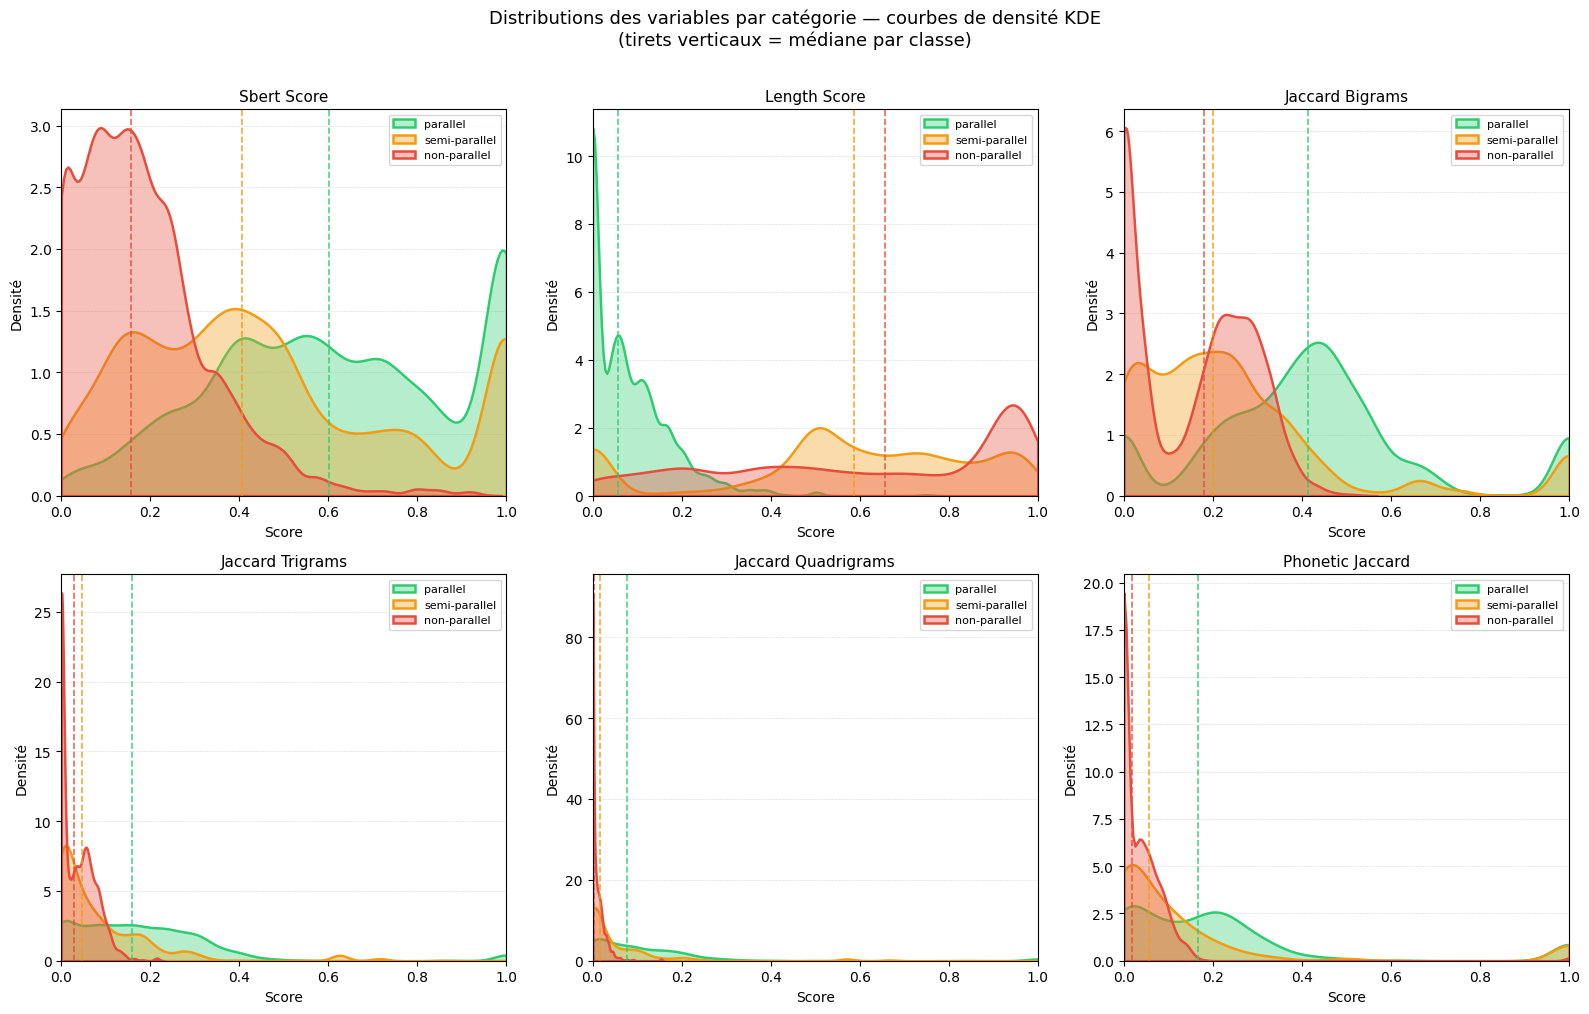

Figure sauvegardée : feature_distributions_kde.png


In [ ]:
!pip install seaborn

CLASS_COLORS = {
    "parallel":      "#2ecc71",
    "semi-parallel": "#f39c12",
    "non-parallel":  "#e74c3c"
}

numeric_features = [
    "sbert_score",
    "length_score",
    "jaccard_bigrams",
    "jaccard_trigrams",
    "jaccard_quadrigrams",
    "phonetic_jaccard",
]

if len(df) < 6:
    print("Dataset too small for meaningful plots.")
else:
    import scipy.stats as stats  # implicitly used by kde plot
    import seaborn as sns

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, feature in enumerate(numeric_features):
        ax = axes[i]
        for class_label, color in CLASS_COLORS.items():
            subset = df[df["class"] == class_label][feature].dropna()
            if len(subset) < 5:
                continue
            sns.kdeplot(
                subset,
                ax=ax,
                color=color,
                label=class_label,
                fill=True,
                alpha=0.35,
                linewidth=1.8,
                bw_adjust=0.6,   # moderate smoothing
                clip=(0, 1),
            )
            # Vertical line for each class mean
            ax.axvline(
                subset.median(),
                color=color,
                linestyle="--",
                linewidth=1.2,
                alpha=0.85,
            )

        ax.set_title(feature.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("Score")
        ax.set_ylabel("Densité")
        ax.set_xlim(0, 1)
        ax.legend(fontsize=8)
        ax.yaxis.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
        ax.set_axisbelow(True)

    plt.suptitle("Distributions des variables par catégorie — courbes de densité KDE\n"
                 "(tirets verticaux = médiane par classe)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("feature_distributions_kde.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : feature_distributions_kde.png")

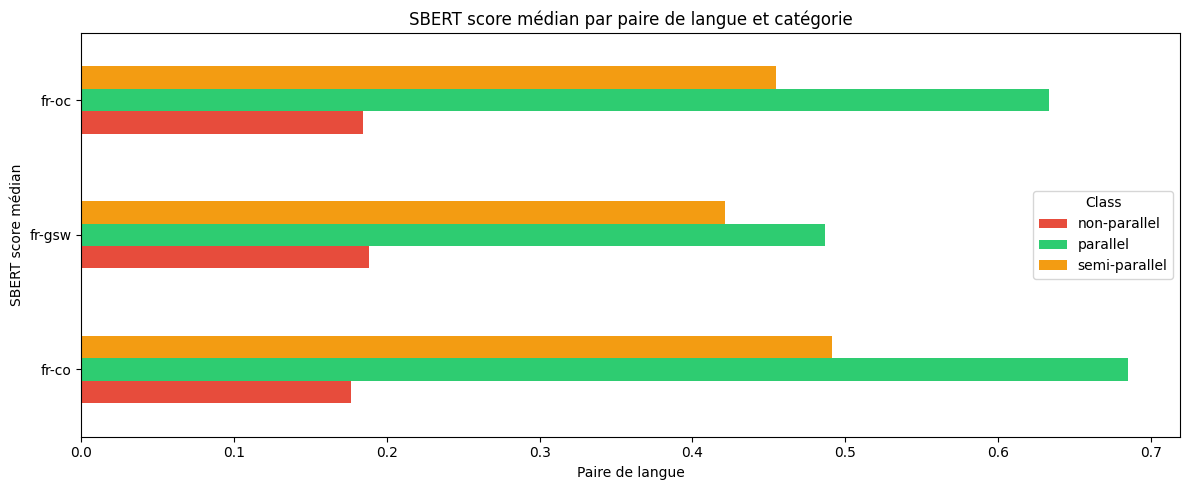

Figure saved: sbert_by_language_pair.png


In [ ]:
# ── Common helper ─────────────────────────────────────────────────────────────
def plot_sbert_bars(data: pd.DataFrame, group_col: str, title: str, fname: str):
    pivot = data.groupby([group_col, "class"])["sbert_score"].mean().unstack()

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(
        kind="barh", ax=ax,
        color=[CLASS_COLORS.get(c, "grey") for c in pivot.columns]
    )
    plt.rwidth = 0.8
    ax.set_title(title)
    ax.set_xlabel("Paire de langue")
    ax.set_ylabel("SBERT score médian")
    ax.legend(title="Class")
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Figure saved: {fname}")

# ── Graphs ──────────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 10})  # Arbitrary

if len(df) >= 6:
    # By language pair
    plot_sbert_bars(
        df, "language_pair",
        "SBERT score médian par paire de langue et catégorie",
        "sbert_by_language_pair.png"
    )

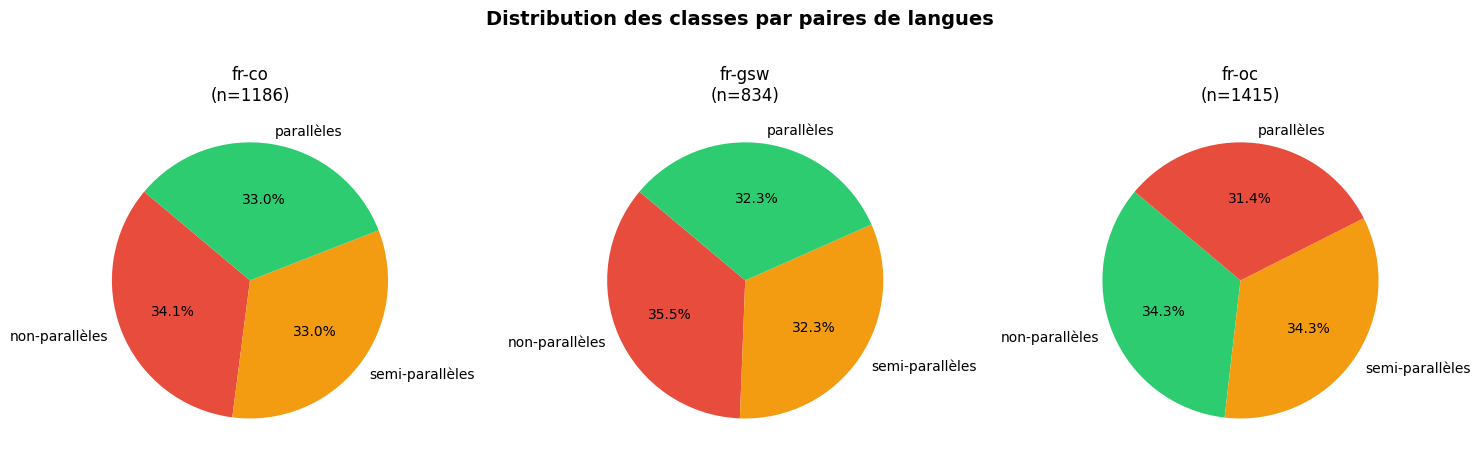

Figure saved: pie_by_language.png


In [ ]:
# ── Helper pie chart ──────────────────────────────────────────────────────────
def plot_class_pie(data: pd.DataFrame, group_col: str | None, title: str, fname: str):
    """
    Creates a pie chart showing the distribution of classes in the dataset.
    """
    if group_col is None:
        counts = data["class"].value_counts()
        colors = [CLASS_COLORS.get(c, "grey") for c in counts.index]

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.pie(
            counts,
            labels=counts.index,
            colors=colors,
            autopct="%1.1f%%",
            startangle=140
        )
        ax.set_title(title)

    else:
        groups = sorted(data[group_col].unique())
        n = len(groups)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
        axes = np.array(axes).flatten()

        for i, grp in enumerate(groups):
            ax = axes[i]
            counts = data.loc[data[group_col] == grp, "class"].value_counts()
            colors = [CLASS_COLORS.get(c, "grey") for c in counts.index]
            ax.pie(
                counts,
                labels=["non-parallèles","semi-parallèles","parallèles"],
                colors=colors,
                autopct="%1.1f%%",
                startangle=140
            )
            ax.set_title(f"{grp}\n(n={len(data[data[group_col] == grp])})")

        # Mask empty axes if the grid is not full
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved: {fname}")


# ── Three pie charts ──────────────────────────────────────────────────────────
if len(df) >= 6:
    # Regional languages
    plot_class_pie(
        df, "language_pair",
        "Distribution des classes par paires de langues",
        "pie_by_language.png"
    )



---


## Extraits par sous-ensembles

In [ ]:
def display_examples(df, class_label, n=3):
    """Display n random examples for a given class label."""
    print(f"\n{'='*70}")
    print(f" Examples: {class_label.upper()}")
    print('='*70)
    subset = df[df["class"] == class_label]
    if subset.empty:
        print("  (no pairs in this category)")
        return
    for _, row in subset.sample(min(n, len(subset))).iterrows():
        print(f"  FR             : {row['fr_sentence'][:95]}")
        print(f"  LR             : {row['lr_sentence'][:95]}")
        print(f"  Language pair  : {row['language_pair']}")
        print(f"  SBERT          : {row['sbert_score']:.4f}")
        print(f"  Length score   : {row['length_score']:.4f}")
        print(f"  Jaccard-3      : {row['jaccard_trigrams']:.4f}")
        print(f"  Phonetic       : {row['phonetic_jaccard']:.4f}")
        print()

display_examples(df, "parallel")
display_examples(df, "semi-parallel")
display_examples(df, "non-parallel")


 Examples: PARALLEL
  FR             : Ainsi, la bise a dû reconnaître que le soleil était le plus fort des deux.
  LR             : Cusì, a tramuntana hà avutu à ricunnosce chì u sole era u più forte di i dui.
  Language pair  : fr-co
  SBERT          : 0.5622
  Length score   : 0.1176
  Jaccard-3      : 0.0787
  Phonetic       : 0.1250

  FR             : 2.
  LR             : 2.
  Language pair  : fr-co
  SBERT          : 1.0000
  Length score   : 0.0000
  Jaccard-3      : 0.0000
  Phonetic       : 0.0000

  FR             : Préambule
  LR             : Introitu
  Language pair  : fr-co
  SBERT          : 0.6471
  Length score   : 0.0000
  Jaccard-3      : 0.0000
  Phonetic       : 0.0000


 Examples: SEMI-PARALLEL
  FR             : Alors le soleil a commencé à briller et au bout d'un moment, le voyageur, réchauffé, a ôté son 
  LR             : Alòr le solelh comencèt de brilhar e au bot d'un moment
  Language pair  : fr-oc
  SBERT          : 0.4764
  Length score   : 0.4211
  Ja

## Exporte les dataset annotés

In [ ]:
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print(f"Dataset exported: {OUTPUT_FILE}")
print(f"\nClass distribution:")
print(df["class"].value_counts().to_string())
print(f"\nLanguage pair distribution:")
print(df["language_pair"].value_counts().to_string())

feature_columns = [
    c for c in df.columns
    if c not in ["fr_sentence", "lr_sentence", "language_pair", "class"]
]
print(f"\nFeature columns: {feature_columns}")
print("\n! Ready for the logistic regression classifier notebook. !")

Dataset exported: similarity_dataset.csv

Class distribution:
class
non-parallel     1145
parallel         1145
semi-parallel    1145

Language pair distribution:
language_pair
fr-oc     1415
fr-co     1186
fr-gsw     834

Feature columns available for the classifier: ['binary_class', 'sbert_score', 'length_score', 'jaccard_bigrams', 'jaccard_trigrams', 'jaccard_quadrigrams', 'phonetic_jaccard']

✔ Ready for the logistic regression classifier notebook.
